# M1.Ex4: Modeling Non-linear Patterns

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex4_non-linear.ipynb)
- Raw Dataset: [bmi_and_life_expectancy.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

### Step 1. Load the data


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv")
df.head()

,Country,Life expectancy,BMI
0,Afghanistan,52.8,20.62058
1,Albania,76.8,26.44657
2,Algeria,75.5,24.59620
3,Andorra,84.6,27.63048
4,Angola,56.7,22.25083


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = df[['BMI']]         
y = df['Life expectancy']

### Step 2.b print the type of each

In [4]:
print("Type of X:", type(X))
print("Type of y:", type(y))

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [5]:
print("Target dtype:", y.dtype)
print()
print("The target 'Life expectancy' is NUMERICAL (continuous float values).")
print("Therefore, the task is REGRESSION.")

Target dtype: float64

The target 'Life expectancy' is NUMERICAL (continuous float values).
Therefore, the task is REGRESSION.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print(f"X shape: {X.shape}  -> {X.shape[0]} samples, {X.shape[1]} feature(s)")
print(f"y shape: {y.shape}  -> {y.shape[0]} samples")

X shape: (163, 1)  -> 163 samples, 1 feature(s)
y shape: (163,)  -> 163 samples


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
summary = df[['BMI', 'Life expectancy']].agg(['min', 'max', 'median', 'mean', 'std'])
print(summary)

              BMI  Life expectancy
min     19.866920        44.500000
max     30.995630        84.600000
median  25.320540        71.800000
mean    24.792378        69.666933
std      2.427900         8.981933


### Step 5. Plot the feature vs the target

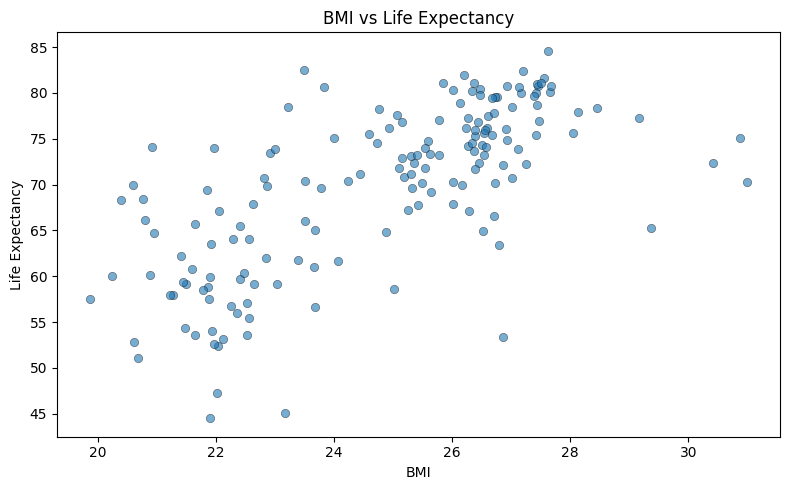

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, edgecolors='k', linewidths=0.4)
plt.xlabel('BMI')
plt.ylabel('Life Expectancy')
plt.title('BMI vs Life Expectancy')
plt.tight_layout()
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [9]:
correlation = X['BMI'].corr(y)
print(f"Pearson correlation (BMI vs Life Expectancy): {correlation:.3f}")
print()
print("The relationship is INCREASING: countries with higher BMI tend to have higher life expectancy.")
print("However, the scatter plot suggests the relationship is non-linear (curve flattens at higher BMI values).")

Pearson correlation (BMI vs Life Expectancy): 0.681

The relationship is INCREASING: countries with higher BMI tend to have higher life expectancy.
However, the scatter plot suggests the relationship is non-linear (curve flattens at higher BMI values).


### Step 7. Make two modeling techniques

First model is just a Linear Regression model: `from sklearn.linear_model import LinearRegression`

Second model: Use one of the previously mentioned methods to model a non-linear relationship

1. `from sklearn.tree import DecisionTreeRegressor`
2. or `from sklearn.preprocessing import PolynomialFeatures`

In [10]:
# Model 1: Linear Regression
model_linear = LinearRegression()

# Model 2: Polynomial Regression (degree=3 captures the curve)
model_poly = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression()
)

print("Model 1:", model_linear)
print("Model 2:", model_poly)

Model 1: LinearRegression()
Model 2: Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('linearregression', LinearRegression())])


### Step 8. Split the dataset into train and test sets

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")

Train size: 130 samples
Test size:  33 samples


### Step 9. Train both models on the training set

/Users/abdulazizalmousa/Desktop/SDAIA bootcamp/SDAIA AAI Bootcamp - Abdulaziz Almousa repo/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/abdulazizalmousa/Desktop/SDAIA bootcamp/SDAIA AAI Bootcamp - Abdulaziz Almousa repo/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


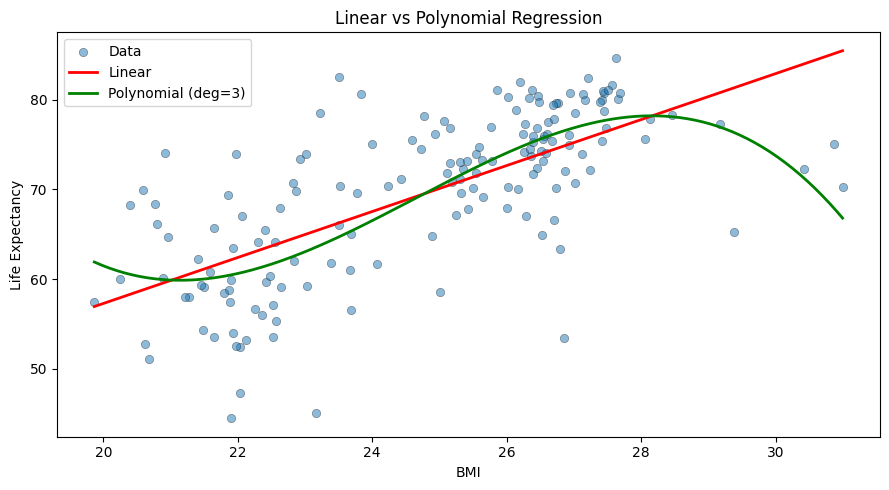

In [12]:
model_linear.fit(X_train, y_train)
model_poly.fit(X_train, y_train)

# Visualize both fits
X_range = np.linspace(X['BMI'].min(), X['BMI'].max(), 300).reshape(-1, 1)

plt.figure(figsize=(9, 5))
plt.scatter(X, y, alpha=0.5, edgecolors='k', linewidths=0.4, label='Data')
plt.plot(X_range, model_linear.predict(X_range), color='red',   linewidth=2, label='Linear')
plt.plot(X_range, model_poly.predict(X_range),   color='green', linewidth=2, label='Polynomial (deg=3)')
plt.xlabel('BMI')
plt.ylabel('Life Expectancy')
plt.title('Linear vs Polynomial Regression')
plt.legend()
plt.tight_layout()
plt.show()

### Step 10. Evaluate and compare which of the two models score better on the `train` set

In [13]:
r2_linear_train = r2_score(y_train, model_linear.predict(X_train))
r2_poly_train   = r2_score(y_train, model_poly.predict(X_train))

print(f"Train R² - Linear Regression:      {r2_linear_train:.4f}")
print(f"Train R² - Polynomial Regression:  {r2_poly_train:.4f}")
print()
better_train = 'Polynomial' if r2_poly_train > r2_linear_train else 'Linear'
print(f"Better on train set: {better_train} Regression")

Train R² - Linear Regression:      0.4940
Train R² - Polynomial Regression:  0.5758

Better on train set: Polynomial Regression


### Step 11. Evaluate and compare which of the two models score better on the `test` set